# Forecasting Faults in Electrical System Equipment to predict fault for manage the maintenance plan

## 1. Filter and Clean Import/Export CSV Data from GitHub
This script downloads a CSV file containing import/export trade data from a public GitHub repository.
It cleans the data by stripping whitespace, filters out rows where the trade flow is equal to "2",
and removes unnecessary columns. The cleaned and filtered data is then saved to a new CSV file
for further analysis or reporting.

In [55]:
import pandas as pd
# Charger le fichier .xlsx (feuille par défaut)
df = pd.read_excel('DATA/Export 2007-2024.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Enregistrer en .csv
df.to_csv('DATA/Export 2007-2024.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

     month_num
0            0
1            1
2            1
3            3
4            4
..         ...
211        214
212        215
213        216
214        217
215        218

[215 rows x 1 columns]


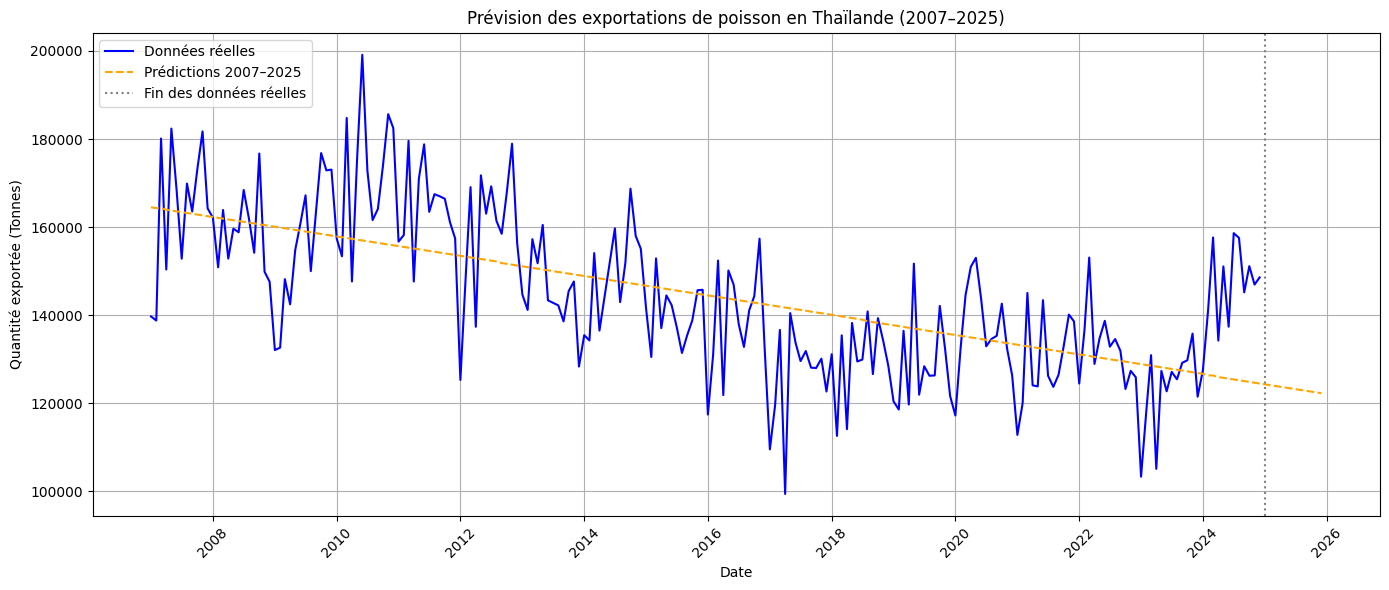

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Charger les données
df = pd.read_csv("DATA/Export 2007-2024.csv")

# Créer une colonne datetime à partir de Year et Month
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))

def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

df = supprimer_lignes_tous_zero_colonnes(df, [
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
    'Dried Shrimp Quantity (Tons)',
    'Dried Shrimp Value (Million Baht)',
    'Boiled or Steamed Shrimp Quantity (Tons)',
    'Boiled or Steamed Shrimp Value (Million Baht)',
    'Shrimp in Airtight Containers Quantity (Tons)',
    'Shrimp in Airtight Containers Value (Million Baht)',
    'Preserved or Processed Shrimp Quantity (Tons)',
    'Preserved or Processed Shrimp Value (Million Baht)',
    'Shrimp Quantity (Tons)',
    'Shrimp Value (Million Baht)',
    'Chilled/Frozen Fresh Squid Quantity (Tons)',
    'Chilled/Frozen Fresh Squid Value (Million Baht)',
    'Dried Squid Quantity (Tons)',
    'Dried Squid Value (Million Baht)',
    'Processed or Preserved Squid Quantity (Tons)',
    'Processed or Preserved Squid Value (Million Baht)',
    'Smoked squid Quantity (Tons)',
    'Smoked squid Value (Million Baht)',
    'Squid Quantity (Tons)',
    'Squid Value (Million Baht)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
    'Chilled/Frozen Fish Fillets Quantity (Tons)',
    'Chilled/Frozen Fish Fillets Value (Million Baht)',
    'Dried Fish Quantity (Tons)',
    'Dried Fish Value (Million Baht)',
    'Live Fish and Fish Breeding Stock Quantity (Tons)',
    'Live Fish and Fish Breeding Stock Value (Million Baht)',
    'Fish Quantity (Tons)',
    'Fish Value (Million Baht)',
    'Canned Tuna Quantity (Tons)',
    'Canned Tuna Value (Million Baht)',
    'Canned Sardines Quantity (Tons)',
    'Canned Sardines Value (Million Baht)',
    'Other Canned Fish Quantity (Tons)',
    'Other Canned Fish Value (Million Baht)',
    'Canned Crab Quantity (Tons)',
    'Canned Crab Value (Million Baht)',
    'Other Canned Seafood Quantity (Tons)',
    'Other Canned Seafood Value (Million Baht)',
    'Canned Products Quantity (Tons)',
    'Canned Products Value (Million Baht)',
    'Canned Dog and Cat Food Quantity (Tons)',
    'Canned Dog and Cat Food Value (Million Baht)',
    'Processed Seafood Products Quantity (Tons)',
    'Processed Seafood Products Value (Million Baht)',
    'Processed Tuna Products Quantity (Tons)',
    'Processed Tuna Products Value (Million Baht)',
    'Preserved or Processed Crab Quantity (Tons)',
    'Preserved or Processed Crab Value (Million Baht)',
    'Other Processed Seafood Products Quantity (Tons)',
    'Other Processed Seafood Products Value (Million Baht)',
    'Other Fishery Products Quantity (Tons)',
    'Other Fishery Products Value (Million Baht)',
    'Grand Total Quantity (Tons)',
    'Grand Total Value (Million Baht)'])

# Trier les données par date
df = df.sort_values('month')

# Créer une variable temporelle numérique
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')

# Entraînement sur toutes les données disponibles
X = df[['month_num']]
y = df['Grand Total Quantity (Tons)']
model = LinearRegression()
model.fit(X, y)
# Générer des dates de 2007 à fin 2025
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
X_all = pd.DataFrame({'month_num': all_month_nums})

# Prédictions sur toute la période
y_all_pred = model.predict(X_all)

# Affichage
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles", color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions 2007–2025", linestyle="--", color='orange')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande (2007–2025)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2. Classification Models

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 2.1 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

In [57]:
# Cross-validation setup
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### 2.2 Training Classification Models

**1 - Model Training**

The model is created and trained on training data.

---

**2 - Prediction on the test set**

The model makes predictions on the test set to evaluate its performance.

--- 

**3 - Confusion Matrix**

Displays a table showing the number of ***correct and incorrect predictions***.

* Helps analyze ***classification errors***.
* Shows how many ***false positives and false negatives*** are produced.

---

**4 - Classification Report**

Displays the model evaluation metrics with `classification_report()`

* ***Precision***: Proportion of true positive predictions.
* ***Recall***: Ability to detect all positive classes.
* ***F1-score***: Harmonic mean between precision and recall.

---

**6 - AUC-ROC Score**

Calculates the area under the ROC curve, a global indicator of model quality.

* The closer the AUC is to ***1***, the better the model.
* An AUC of ***0.5*** means the model is ***predicting randomly***.

---

**7 - ROC curve**

Plots the ***ROC curve***, which shows the trade-off between the false positive rate and the true positive rate.

* Helps analyze the ***optimal classification threshold***.
* A curve close to the top-left corner indicates a ***good model***.

### 2.3 Applying the Models


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


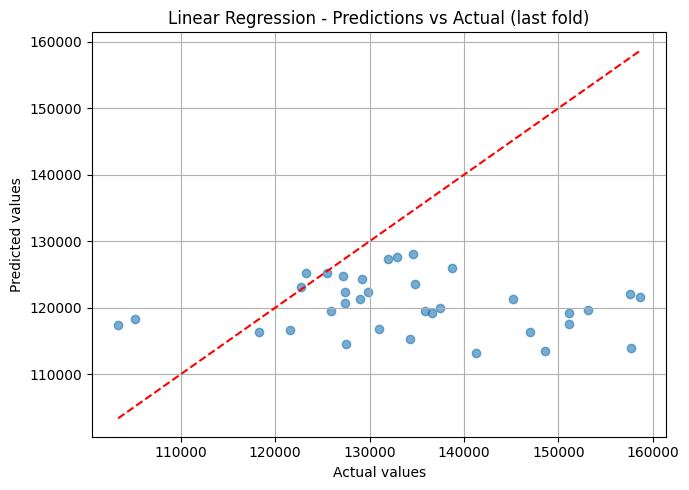


=== SVR ===

--- Fold 1 ---
RMSE: 14754.6254
R²: -0.0687

--- Fold 2 ---
RMSE: 21046.1845
R²: -3.0512

--- Fold 3 ---
RMSE: 28340.8471
R²: -4.9767

--- Fold 4 ---
RMSE: 20275.5112
R²: -2.9318

--- Fold 5 ---
RMSE: 16660.2716
R²: -0.5956


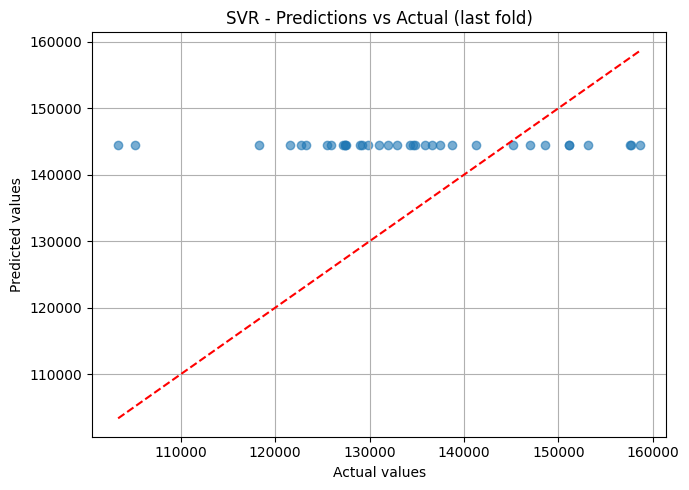


=== Decision Tree ===

--- Fold 1 ---
RMSE: 13157.3056
R²: 0.1501

--- Fold 2 ---
RMSE: 26085.3913
R²: -5.2235

--- Fold 3 ---
RMSE: 13636.5714
R²: -0.3837

--- Fold 4 ---
RMSE: 11038.2821
R²: -0.1653

--- Fold 5 ---
RMSE: 14294.9379
R²: -0.1747


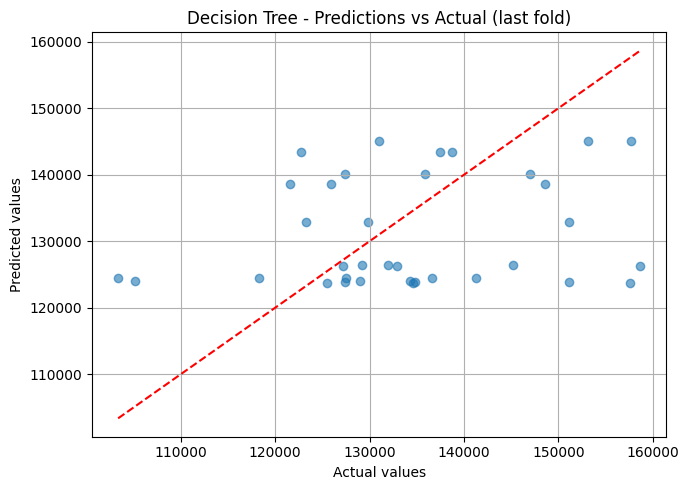


=== Random Forest ===

--- Fold 1 ---
RMSE: 12196.0714
R²: 0.2698

--- Fold 2 ---
RMSE: 18719.3601
R²: -2.2049

--- Fold 3 ---
RMSE: 11743.6145
R²: -0.0262

--- Fold 4 ---
RMSE: 11047.5942
R²: -0.1673

--- Fold 5 ---
RMSE: 12451.6732
R²: 0.1087


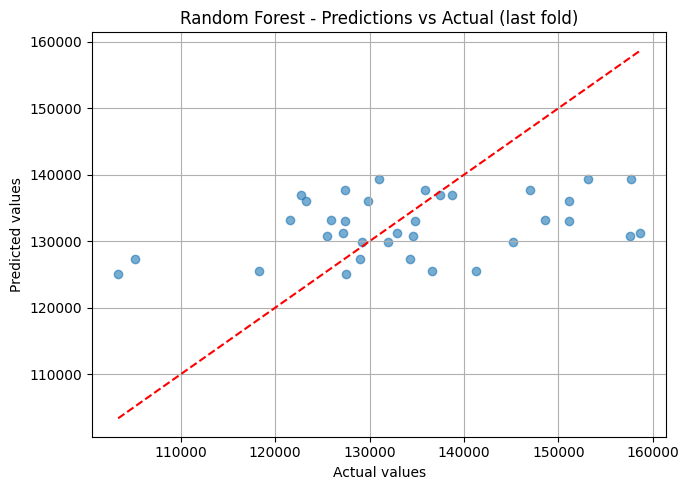


=== KNN ===

--- Fold 1 ---
RMSE: 14292.2445
R²: -0.0028

--- Fold 2 ---
RMSE: 15791.6621
R²: -1.2808

--- Fold 3 ---
RMSE: 13956.2199
R²: -0.4493

--- Fold 4 ---
RMSE: 11065.9176
R²: -0.1712

--- Fold 5 ---
RMSE: 13313.3142
R²: -0.0189


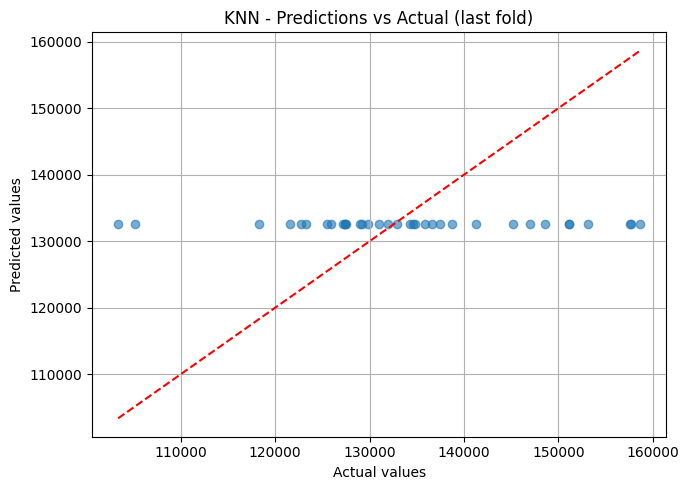


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20215.4880  4672.8087  -2.3248  1.7893
Decision Tree      15642.4976  5334.2041  -1.1594  2.0392
Random Forest      13231.6627  2784.9631  -0.4040  0.9120
KNN                13683.8717  1541.3026  -0.3846  0.4759
Index([  0,   1,   1,   3,   4,   5,   6,   7,   8,   9,
       ...
       282, 283, 284, 285, 286, 287, 288, 289, 290, 291],
      dtype='int32', length=288)


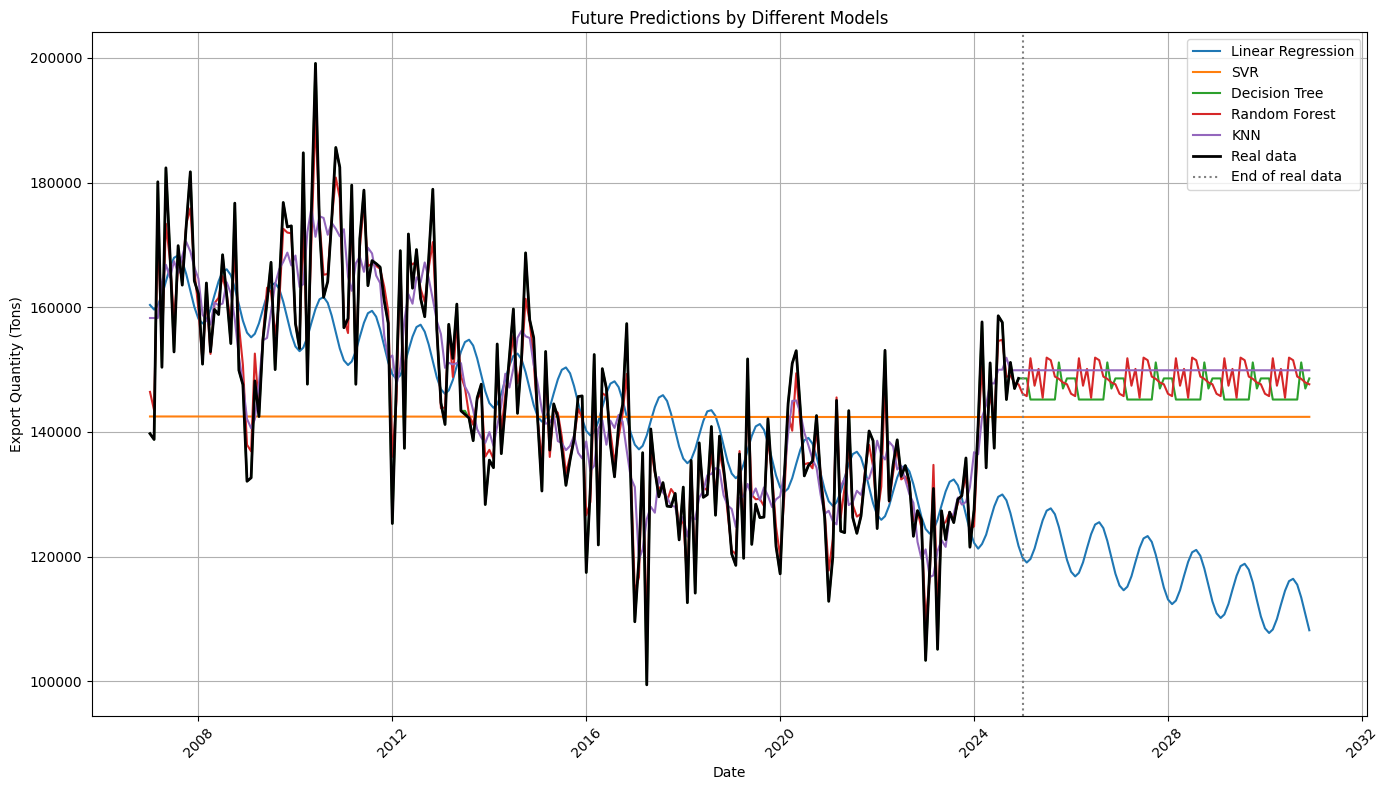

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# --- Chargement et préparation des données ---

#df = pd.read_csv("DATA/Export 2007-2024.csv")

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Variables cycliques pour gérer la saisonnalité
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Modèles à tester ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        if i == tscv.get_n_splits() - 1:  # Plot last fold predictions
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Résumé des résultats ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Prédiction future sur toutes les données ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})


plt.figure(figsize=(14, 8))

for name, model in models.items():
    # Re-train model on all data
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




In [59]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Espaces d'hyperparamètres pour chaque modèle
param_grids = {
    "Linear Regression": {},  # Pas d’hyperparamètre à tuner ici
    
    "SVR": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1, 0.5]
    },
    
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "KNN": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
    }
}

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

best_models = {}
results = {}

for name, model in models.items():
    print(f"\n=== Hyperparameter tuning for {name} ===")
    
    param_grid = param_grids.get(name, {})
    
    # Si pas d'hyperparamètre, on skip la recherche
    if not param_grid:
        print("No hyperparameters to tune for this model.")
        model.fit(X, y)
        best_models[name] = model
        continue
    
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    best_models[name] = grid_search.best_estimator_
    
    best_rmse = (-grid_search.best_score_) ** 0.5
    
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    
    results[name] = {
        "Best Params": grid_search.best_params_,
        "Best CV RMSE": best_rmse
    }

# Affichage résumé
import pandas as pd
summary_df = pd.DataFrame(results).T
print("\n=== Summary of Hyperparameter Tuning Results ===")
print(summary_df)



=== Hyperparameter tuning for Linear Regression ===
No hyperparameters to tune for this model.

=== Hyperparameter tuning for SVR ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for SVR: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV RMSE: 20590.6514

=== Hyperparameter tuning for Decision Tree ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE: 13921.7242

=== Hyperparameter tuning for Random Forest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 13357.0428

=== Hyperparameter tuning for KNN ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best CV RMSE: 13054.7777

=== Summary of Hyperparameter 


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


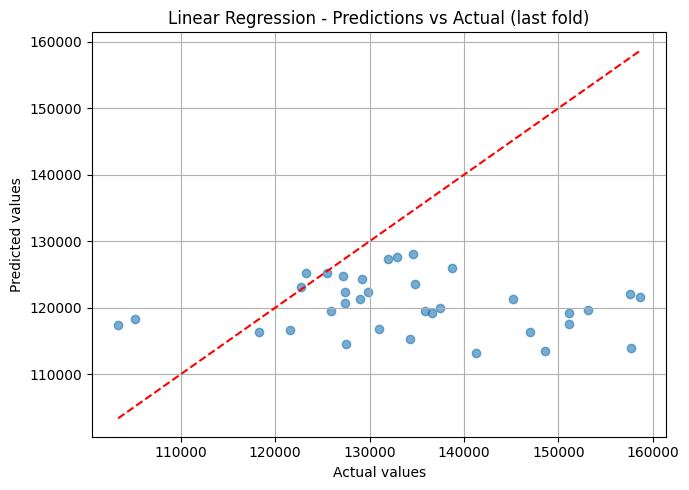


=== SVR ===

--- Fold 1 ---
RMSE: 14754.5118
R²: -0.0687

--- Fold 2 ---
RMSE: 21051.6542
R²: -3.0533

--- Fold 3 ---
RMSE: 28183.5888
R²: -4.9105

--- Fold 4 ---
RMSE: 19837.8669
R²: -2.7639

--- Fold 5 ---
RMSE: 16466.6702
R²: -0.5587


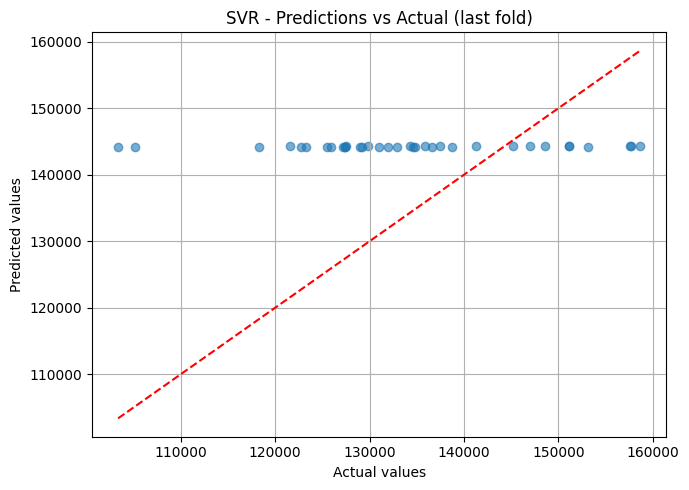


=== Decision Tree ===

--- Fold 1 ---
RMSE: 11500.9926
R²: 0.3506

--- Fold 2 ---
RMSE: 18124.6197
R²: -2.0045

--- Fold 3 ---
RMSE: 14284.2584
R²: -0.5183

--- Fold 4 ---
RMSE: 12154.4430
R²: -0.4129

--- Fold 5 ---
RMSE: 12511.0683
R²: 0.1002


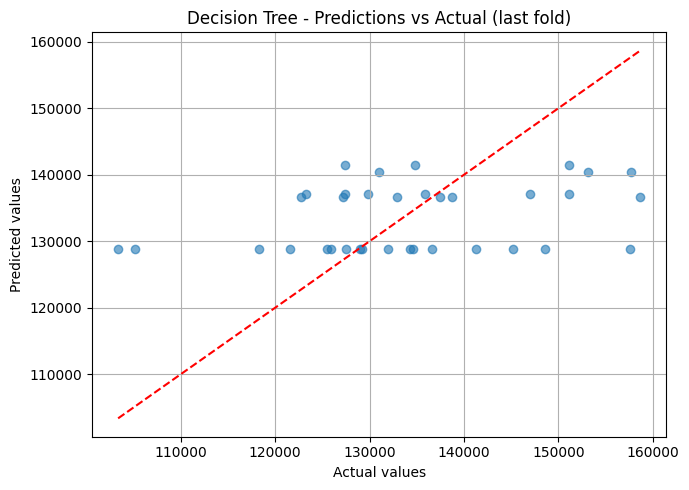


=== Random Forest ===

--- Fold 1 ---
RMSE: 11887.9191
R²: 0.3062

--- Fold 2 ---
RMSE: 18435.9713
R²: -2.1086

--- Fold 3 ---
RMSE: 11293.9954
R²: 0.0509

--- Fold 4 ---
RMSE: 11289.2980
R²: -0.2189

--- Fold 5 ---
RMSE: 12472.1680
R²: 0.1058


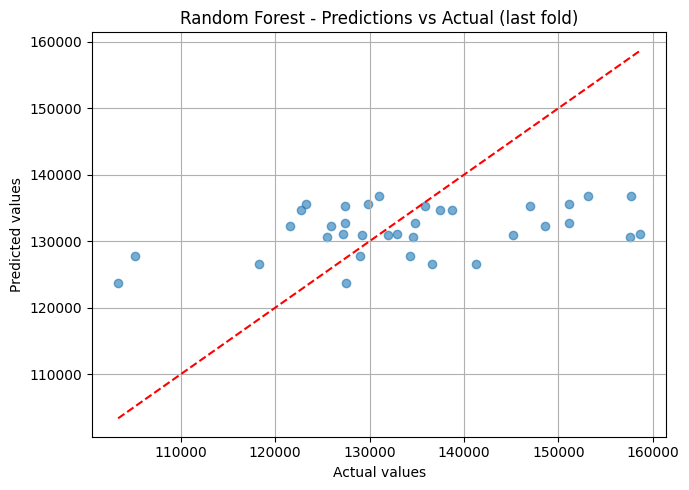


=== KNN ===

--- Fold 1 ---
RMSE: 14421.3840
R²: -0.0210

--- Fold 2 ---
RMSE: 11139.6225
R²: -0.1350

--- Fold 3 ---
RMSE: 11959.5515
R²: -0.0643

--- Fold 4 ---
RMSE: 14250.4425
R²: -0.9422

--- Fold 5 ---
RMSE: 13189.4890
R²: -0.0000


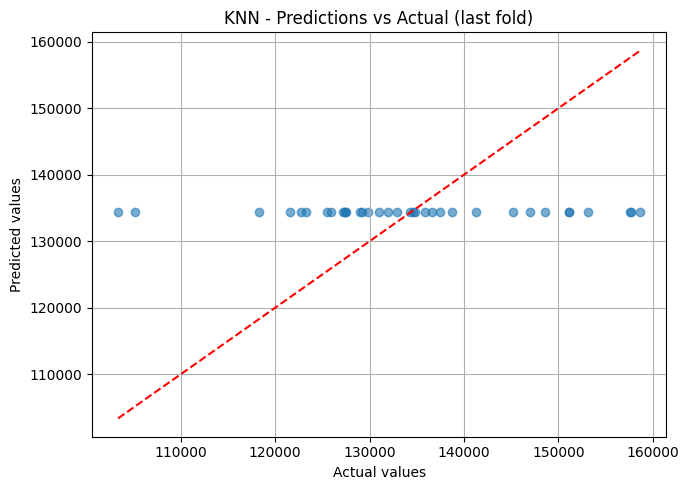


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20058.8584  4649.4222  -2.2710  1.7666
Decision Tree      13715.0764  2389.7874  -0.4970  0.8192
Random Forest      13075.8703  2715.6320  -0.3729  0.8839
KNN                12992.0979  1277.7379  -0.2325  0.3579


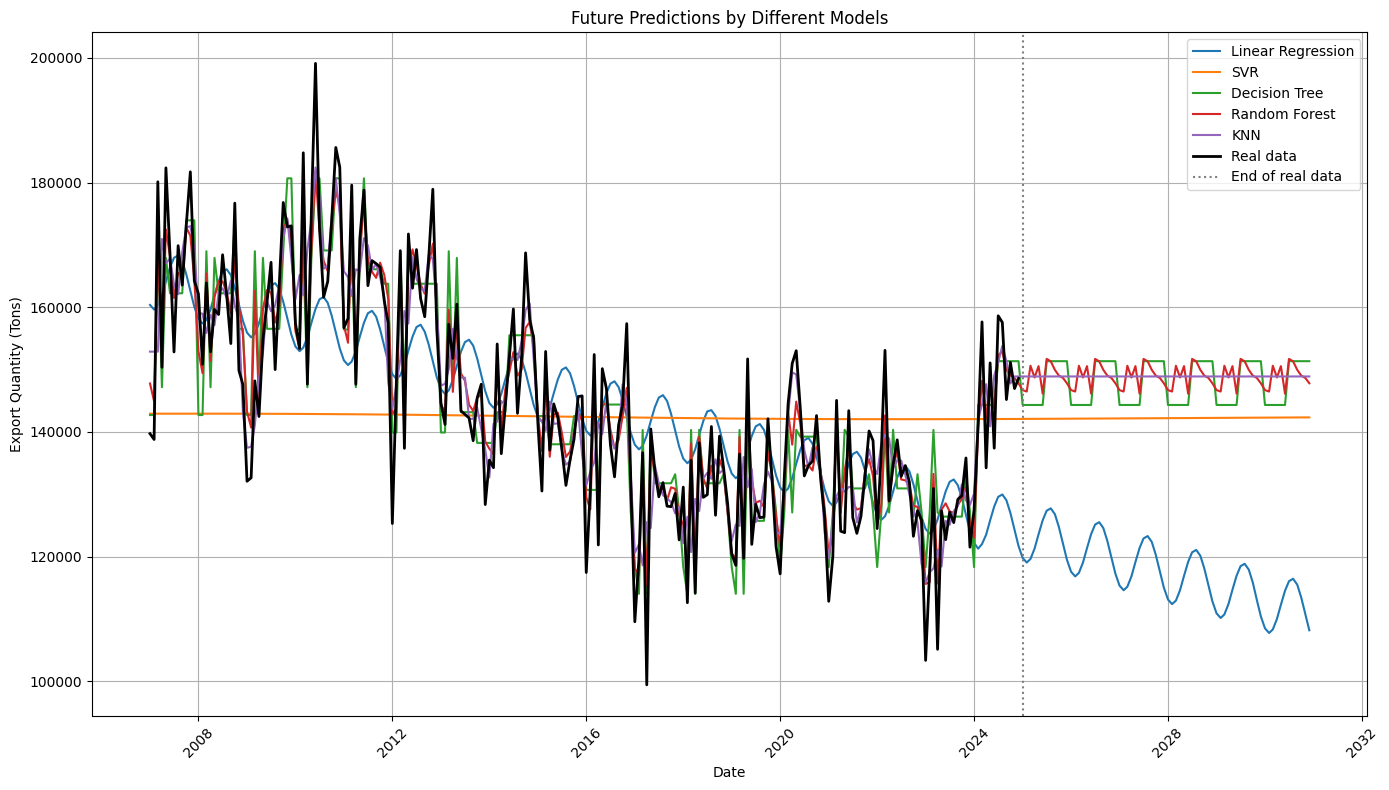

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# --- Chargement et préparation des données ---

#df = pd.read_csv("DATA/Export 2007-2024.csv")

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Variables cycliques pour gérer la saisonnalité
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Modèles à tester ---

 


models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(C= 10, epsilon= 0.01, gamma= 'scale'),
    "Decision Tree": DecisionTreeRegressor(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10),
    "Random Forest": RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200),
    "KNN": KNeighborsRegressor(n_neighbors= 3, p= 1, weights= 'uniform')
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        if i == tscv.get_n_splits() - 1:  # Plot last fold predictions
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Résumé des résultats ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Prédiction future sur toutes les données ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})

plt.figure(figsize=(14, 8))

for name, model in models.items():
    # Re-train model on all data
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




RMSE CV: Moyenne = 13156.47, Écart-type = 2993.35


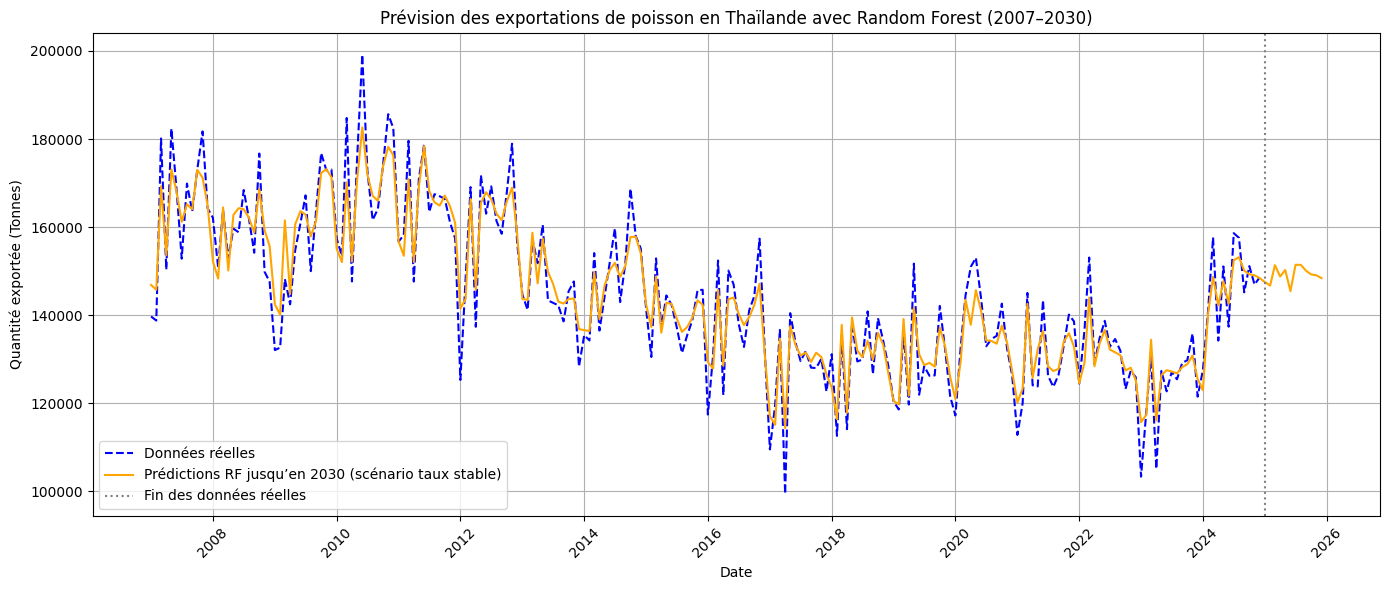

In [61]:
import pandas as pd

summary_df = pd.DataFrame(results).T.round(4)

# Préparer la colonne de dates
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')

# Ajouter des variables temporelles
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

# Features + cible
X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# Modèle
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Entraînement complet sur 2007–2024
model.fit(X, y)

# ---------- SCÉNARIO SIMPLE POUR 2025–2030 ----------
# Créer tous les mois de la période complète
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

# Étendre 'Price baht to usd' :
# - pour les mois connus : utiliser les vraies valeurs
# - pour 2025–2030 : utiliser une valeur constante (moyenne)
last_real_month = df['month'].max()
price_projection_start = last_real_month + pd.DateOffset(months=1)



# Créer DataFrame de prédiction complet
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

# Prédiction
y_all_pred = model.predict(X_all)

# ---------- AFFICHAGE ----------
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles", linestyle="--", color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions RF jusqu’en 2030 (scénario taux stable)", color='orange')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Random Forest (2007–2030)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


RMSE CV: Moyenne = 12297.70, Écart-type = 2014.41


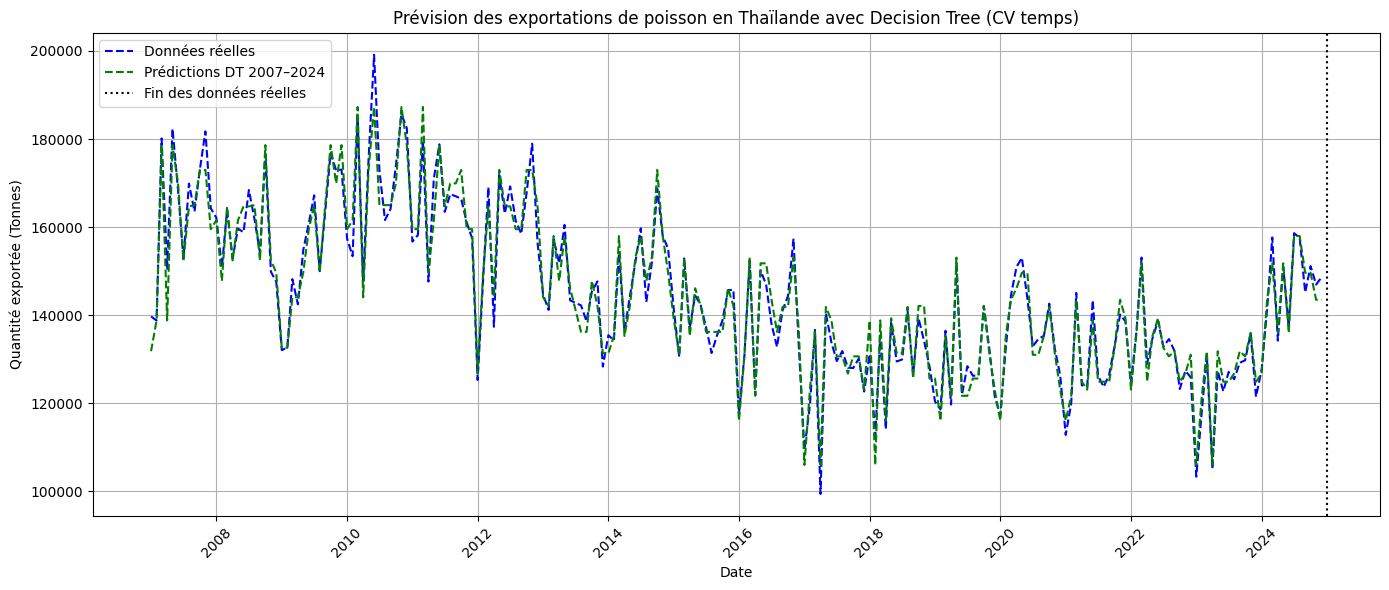

In [116]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt



# Définir features et cible
#X=df[['month_num', 'month_sin', 'month_cos']]
X = df[['month_num', 'month_sin', 'month_cos', 'Grand Total Value (Million Baht)',
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)', 'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
        'Dried Shrimp Quantity (Tons)','Dried Shrimp Value (Million Baht)',
        'Boiled or Steamed Shrimp Quantity (Tons)','Boiled or Steamed Shrimp Value (Million Baht)',
        'Shrimp in Airtight Containers Quantity (Tons)','Shrimp in Airtight Containers Value (Million Baht)',
        'Preserved or Processed Shrimp Quantity (Tons)','Preserved or Processed Shrimp Value (Million Baht)',
        'Shrimp Quantity (Tons)','Shrimp Value (Million Baht)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)', 'Chilled/Frozen Fresh Squid Value (Million Baht)',
        'Dried Squid Quantity (Tons)', 'Dried Squid Value (Million Baht)',
        'Processed or Preserved Squid Quantity (Tons)', 'Processed or Preserved Squid Value (Million Baht)',
        'Smoked squid Quantity (Tons)', 'Smoked squid Value (Million Baht)',
        'Squid Quantity (Tons)','Squid Value (Million Baht)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)', 'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)', 'Chilled/Frozen Fish Fillets Value (Million Baht)',
        'Dried Fish Quantity (Tons)', 'Dried Fish Value (Million Baht)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)', 'Live Fish and Fish Breeding Stock Value (Million Baht)',
        'Fish Quantity (Tons)','Fish Value (Million Baht)',
        'Canned Tuna Quantity (Tons)', 'Canned Tuna Value (Million Baht)',
        'Canned Sardines Quantity (Tons)', 'Canned Sardines Value (Million Baht)',
        'Other Canned Fish Quantity (Tons)', 'Other Canned Fish Value (Million Baht)',
        'Canned Crab Quantity (Tons)', 'Canned Crab Value (Million Baht)',
        'Other Canned Seafood Quantity (Tons)', 'Other Canned Seafood Value (Million Baht)',
        'Canned Products Quantity (Tons)','Canned Products Value (Million Baht)',
        'Canned Dog and Cat Food Quantity (Tons)', 'Canned Dog and Cat Food Value (Million Baht)',
        'Processed Seafood Products Quantity (Tons)', 'Processed Seafood Products Value (Million Baht)',
        'Processed Tuna Products Quantity (Tons)', 'Processed Tuna Products Value (Million Baht)',
        'Preserved or Processed Crab Quantity (Tons)', 'Preserved or Processed Crab Value (Million Baht)',
        'Other Processed Seafood Products Quantity (Tons)', 'Other Processed Seafood Products Value (Million Baht)',
        'Other Fishery Products Quantity (Tons)', 'Other Fishery Products Value (Million Baht)'
        ]]
y = df['Grand Total Quantity (Tons)'].values

# Initialiser le modèle DecisionTree
model = DecisionTreeRegressor(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10)

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Entraîner sur toutes les données
model.fit(X, y)

# Générer les mois jusqu'à 2030
all_months = pd.date_range(start=df['month'].min(), end="2024-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Grand Total Value (Million Baht)' : df['Grand Total Value (Million Baht)'],
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)': df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'], 
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)': df['Chilled/Frozen Fresh Shrimp Value (Million Baht)'],
    'Dried Shrimp Quantity (Tons)': df['Dried Shrimp Quantity (Tons)'], 
    'Dried Shrimp Value (Million Baht)': df['Dried Shrimp Value (Million Baht)'],
    'Boiled or Steamed Shrimp Quantity (Tons)': df['Boiled or Steamed Shrimp Quantity (Tons)'], 
    'Boiled or Steamed Shrimp Value (Million Baht)': df['Boiled or Steamed Shrimp Value (Million Baht)'],
    'Shrimp in Airtight Containers Quantity (Tons)': df['Shrimp in Airtight Containers Quantity (Tons)'],
    'Shrimp in Airtight Containers Value (Million Baht)': df['Shrimp in Airtight Containers Value (Million Baht)'],
    'Preserved or Processed Shrimp Quantity (Tons)': df['Preserved or Processed Shrimp Quantity (Tons)'],
    'Preserved or Processed Shrimp Value (Million Baht)': df['Preserved or Processed Shrimp Value (Million Baht)'],
    'Shrimp Quantity (Tons)' : df['Shrimp Quantity (Tons)'],
    'Shrimp Value (Million Baht)' : df['Shrimp Value (Million Baht)'],
    'Chilled/Frozen Fresh Squid Quantity (Tons)': df['Chilled/Frozen Fresh Squid Quantity (Tons)'],
    'Chilled/Frozen Fresh Squid Value (Million Baht)' : df['Chilled/Frozen Fresh Squid Value (Million Baht)'],
    'Dried Squid Quantity (Tons)': df['Dried Squid Quantity (Tons)'],
    'Dried Squid Value (Million Baht)' : df['Dried Squid Value (Million Baht)'],
    'Processed or Preserved Squid Quantity (Tons)': df['Processed or Preserved Squid Quantity (Tons)'],
    'Processed or Preserved Squid Value (Million Baht)' : df['Processed or Preserved Squid Value (Million Baht)'],
    'Smoked squid Quantity (Tons)':df['Smoked squid Quantity (Tons)'],
    'Smoked squid Value (Million Baht)' :df ['Smoked squid Value (Million Baht)'],
    'Squid Quantity (Tons)': df['Squid Quantity (Tons)'],
    'Squid Value (Million Baht)': df['Squid Value (Million Baht)'],
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)': df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'],
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)' : df['Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)'],
    'Chilled/Frozen Fish Fillets Quantity (Tons)': df['Chilled/Frozen Fish Fillets Quantity (Tons)'],
    'Chilled/Frozen Fish Fillets Value (Million Baht)': df['Chilled/Frozen Fish Fillets Value (Million Baht)'],
    'Dried Fish Quantity (Tons)': df['Dried Fish Quantity (Tons)'],
    'Dried Fish Value (Million Baht)': df['Dried Fish Value (Million Baht)'],
    'Live Fish and Fish Breeding Stock Quantity (Tons)': df['Live Fish and Fish Breeding Stock Quantity (Tons)'],
    'Live Fish and Fish Breeding Stock Value (Million Baht)': df['Live Fish and Fish Breeding Stock Value (Million Baht)'],
    'Fish Quantity (Tons)' :df['Fish Quantity (Tons)'],
    'Fish Value (Million Baht)' : df['Fish Value (Million Baht)'],
    'Canned Tuna Quantity (Tons)': df['Canned Tuna Quantity (Tons)'],
    'Canned Tuna Value (Million Baht)': df['Canned Tuna Value (Million Baht)'],
    'Canned Sardines Quantity (Tons)': df['Canned Sardines Quantity (Tons)'],
    'Canned Sardines Value (Million Baht)' : df['Canned Sardines Value (Million Baht)'],
    'Other Canned Fish Quantity (Tons)': df['Other Canned Fish Quantity (Tons)'],
    'Other Canned Fish Value (Million Baht)': df['Other Canned Fish Value (Million Baht)'],
    'Canned Crab Quantity (Tons)': df['Canned Crab Quantity (Tons)'],
    'Canned Crab Value (Million Baht)': df['Canned Crab Value (Million Baht)'],
    'Other Canned Seafood Quantity (Tons)': df['Other Canned Seafood Quantity (Tons)'],
    'Other Canned Seafood Value (Million Baht)': df['Other Canned Seafood Value (Million Baht)'],
    'Canned Products Quantity (Tons)' : df['Canned Products Quantity (Tons)'],
    'Canned Products Value (Million Baht)' : df['Canned Products Value (Million Baht)'],
    'Canned Dog and Cat Food Quantity (Tons)': df['Canned Dog and Cat Food Quantity (Tons)'],
    'Canned Dog and Cat Food Value (Million Baht)': df['Canned Dog and Cat Food Value (Million Baht)'],
    'Processed Seafood Products Quantity (Tons)': df['Processed Seafood Products Quantity (Tons)'],
    'Processed Seafood Products Value (Million Baht)': df['Processed Seafood Products Value (Million Baht)'],
    'Processed Tuna Products Quantity (Tons)': df['Processed Tuna Products Quantity (Tons)'],
    'Processed Tuna Products Value (Million Baht)': df['Processed Tuna Products Value (Million Baht)'],
    'Preserved or Processed Crab Quantity (Tons)': df['Preserved or Processed Crab Quantity (Tons)'],
    'Preserved or Processed Crab Value (Million Baht)': df['Preserved or Processed Crab Value (Million Baht)'],
    'Other Processed Seafood Products Quantity (Tons)' : df['Other Processed Seafood Products Quantity (Tons)'],
    'Other Processed Seafood Products Value (Million Baht)' : df['Other Processed Seafood Products Value (Million Baht)'],
    'Other Fishery Products Quantity (Tons)' : df['Other Fishery Products Quantity (Tons)'],
    'Other Fishery Products Value (Million Baht)' : df['Other Fishery Products Value (Million Baht)']
})

# Prédictions
y_all_pred = model.predict(X_all)

# Affichage
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Decision Tree (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
